# Week 2 - Task 2.1
## Neural Network in PyTorch

### Objective
Implement a feed-forward neural network using PyTorch,
covering tensors, datasets, dataloaders, loss functions,
training, and evaluation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 1. Creating the Dataset

We will create a small binary classification dataset.

Each sample has two features:
- Hours studied
- Attendance percentage

The target label represents:
- 0 = Fail
- 1 = Pass

In [2]:
X = torch.tensor([
    [1.0, 50.0],
    [2.0, 55.0],
    [2.0, 60.0],
    [3.0, 65.0],
    [3.0, 70.0],
    [4.0, 75.0],
    [4.0, 80.0],
    [5.0, 85.0],
    [5.0, 90.0],
    [6.0, 95.0]
])

y = torch.tensor([
    [0.0],
    [0.0],
    [0.0],
    [1.0],
    [1.0],
    [1.0],
    [1.0],
    [1.0],
    [1.0],
    [1.0]
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([10, 2])
y shape: torch.Size([10, 1])


## 2. Creating a TensorDataset

TensorDataset combines the input features (X) with their target labels (y).

In [3]:
dataset = TensorDataset(X, y)

print("Number of samples:", len(dataset))
print("First sample:", dataset[0])

Number of samples: 10
First sample: (tensor([ 1., 50.]), tensor([0.]))


## 3. Creating a DataLoader

The DataLoader divides the dataset into batches.

A batch allows the model to process multiple samples at a time.

In [4]:
dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

for batch_X, batch_y in dataloader:
    print("Batch X:", batch_X)
    print("Batch y:", batch_y)
    break

Batch X: tensor([[ 2., 60.],
        [ 4., 80.]])
Batch y: tensor([[0.],
        [1.]])


## 4. Building the Neural Network

The network will contain:
- An input layer with 2 features
- A hidden layer with 8 neurons
- An output layer with 1 neuron

ReLU will be used as the activation function for the hidden layer.

In [5]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)

        return x


model = NeuralNetwork()

print(model)

NeuralNetwork(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


## 5. Loss Function and Optimizer

The loss function measures how far the model predictions are from the true labels.

The optimizer updates the model weights to reduce the loss during training.

In [6]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 6. Training the Neural Network

During training, the model will:
1. Make predictions
2. Calculate the loss
3. Calculate gradients using backpropagation
4. Update the weights using the optimizer

In [7]:
epochs = 100

loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for batch_X, batch_y in dataloader:

        # Forward pass
        predictions = model(batch_X)

        # Calculate loss
        loss = criterion(predictions, batch_y)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    loss_history.append(average_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {average_loss:.4f}"
        )

Epoch [10/100], Loss: 0.5446
Epoch [20/100], Loss: 0.5427
Epoch [30/100], Loss: 0.5429
Epoch [40/100], Loss: 0.5410
Epoch [50/100], Loss: 0.5377
Epoch [60/100], Loss: 0.5368
Epoch [70/100], Loss: 0.5337
Epoch [80/100], Loss: 0.5316
Epoch [90/100], Loss: 0.5312
Epoch [100/100], Loss: 0.5276


## 7. Evaluating the Model

After training, we will evaluate how many predictions
the model classified correctly.

In [8]:
with torch.no_grad():

    logits = model(X)

    probabilities = torch.sigmoid(logits)

    predictions = (probabilities >= 0.5).float()

    accuracy = (predictions == y).float().mean()

print(f"Accuracy: {accuracy.item() * 100:.2f}%")

Accuracy: 70.00%


## 8. Loss Visualization

The loss curve helps us observe how the training loss changes over time.

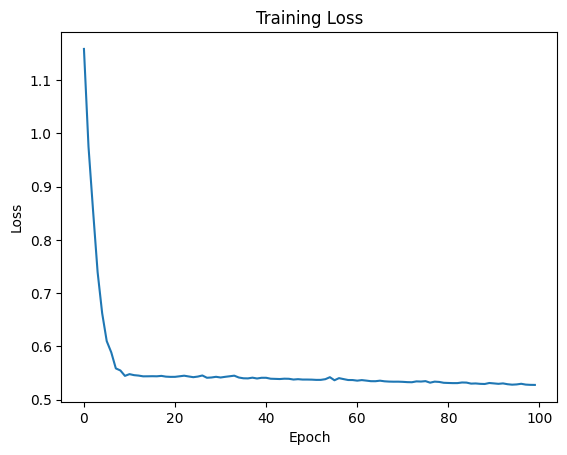

In [9]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

## 9. Conclusion

The feed-forward neural network was successfully implemented
using PyTorch.

The project covered tensors, TensorDataset, DataLoader,
a neural network architecture, a loss function, an optimizer,
training with backpropagation, and model evaluation.

Task 2.2 — CNN Image Classifier


# Week 2 - Task 2.2
## CNN Image Classifier

### Objective
Build and train a Convolutional Neural Network (CNN)
using PyTorch to classify images.

The task includes:
- Preparing an image dataset
- Building a CNN model
- Training the model
- Evaluating the model
- Reporting the classification accuracy

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

## 1. Load and Prepare the Dataset

We will use the CIFAR-10 dataset for image classification.
The dataset contains 10 different image classes.

We will apply transformations to prepare the images for training.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

100%|██████████| 170M/170M [35:39<00:00, 79.7kB/s]


Training images: 50000
Testing images: 10000


## 2. Build the CNN Model

The CNN uses convolutional layers to extract features from images,
pooling layers to reduce the spatial dimensions, and fully connected
layers to classify the images.

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN()
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [4]:
model = CNN()
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [5]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [6]:
epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/5], Loss: 1.3469
Epoch [2/5], Loss: 0.9724
Epoch [3/5], Loss: 0.8209
Epoch [4/5], Loss: 0.7174
Epoch [5/5], Loss: 0.6218


In [7]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.93%


In [8]:
print("CNN Image Classifier Results")
print("----------------------------")
print("Dataset: CIFAR-10")
print("Training images: 50,000")
print("Testing images: 10,000")
print("Epochs: 5")
print(f"Test Accuracy: {accuracy:.2f}%")

CNN Image Classifier Results
----------------------------
Dataset: CIFAR-10
Training images: 50,000
Testing images: 10,000
Epochs: 5
Test Accuracy: 70.93%


In [9]:
import torch.optim as optim

experiments = [
    ("Baseline", "Adam", 0.001),
    ("Adam_LR_0005", "Adam", 0.0005),
    ("Adam_LR_001", "Adam", 0.01),
    ("SGD_LR_001", "SGD", 0.001)
]

results = []

for name, optimizer_name, lr in experiments:

    # Create a fresh model for each experiment
    experiment_model = CNN()

    # Select optimizer
    if optimizer_name == "Adam":
        experiment_optimizer = optim.Adam(
            experiment_model.parameters(),
            lr=lr
        )
    else:
        experiment_optimizer = optim.SGD(
            experiment_model.parameters(),
            lr=lr
        )

    criterion = nn.CrossEntropyLoss()

    # Train
    epochs = 5

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in train_loader:

            outputs = experiment_model(images)

            loss = criterion(outputs, labels)

            experiment_optimizer.zero_grad()
            loss.backward()
            experiment_optimizer.step()

            running_loss += loss.item()

    # Evaluate
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            outputs = experiment_model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    results.append({
        "Experiment": name,
        "Optimizer": optimizer_name,
        "Learning Rate": lr,
        "Epochs": epochs,
        "Test Accuracy": accuracy
    })

    print(
        f"{name}: "
        f"Optimizer={optimizer_name}, "
        f"LR={lr}, "
        f"Accuracy={accuracy:.2f}%"
    )

Baseline: Optimizer=Adam, LR=0.001, Accuracy=72.70%
Adam_LR_0005: Optimizer=Adam, LR=0.0005, Accuracy=70.56%
Adam_LR_001: Optimizer=Adam, LR=0.01, Accuracy=10.00%
SGD_LR_001: Optimizer=SGD, LR=0.001, Accuracy=30.82%
